## Load Library and Dataset

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Survival analysis
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# Random Survival Forest
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline   
from sklearn.inspection import permutation_importance

# Dataset loader
from ucimlrepo import fetch_ucirepo

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Fetch dataset
study_175 = fetch_ucirepo(id=890)

# Features and targets
X = study_175.data.features
y = study_175.data.targets

# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

## Data Analysis

In [40]:
df.head()


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     2139 non-null   int64  
 1   trt      2139 non-null   int64  
 2   age      2139 non-null   int64  
 3   wtkg     2139 non-null   float64
 4   hemo     2139 non-null   int64  
 5   homo     2139 non-null   int64  
 6   drugs    2139 non-null   int64  
 7   karnof   2139 non-null   int64  
 8   oprior   2139 non-null   int64  
 9   z30      2139 non-null   int64  
 10  zprior   2139 non-null   int64  
 11  preanti  2139 non-null   int64  
 12  race     2139 non-null   int64  
 13  gender   2139 non-null   int64  
 14  str2     2139 non-null   int64  
 15  strat    2139 non-null   int64  
 16  symptom  2139 non-null   int64  
 17  treat    2139 non-null   int64  
 18  offtrt   2139 non-null   int64  
 19  cd40     2139 non-null   int64  
 20  cd420    2139 non-null   int64  
 21  cd80     2139 

In [42]:
df.isnull().sum()

time       0
trt        0
age        0
wtkg       0
hemo       0
homo       0
drugs      0
karnof     0
oprior     0
z30        0
zprior     0
preanti    0
race       0
gender     0
str2       0
strat      0
symptom    0
treat      0
offtrt     0
cd40       0
cd420      0
cd80       0
cd820      0
cid        0
dtype: int64

In [43]:
df.describe(include='all')

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
count,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,...,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000
mean,879.098177,1.520804,35.248247,75.125311,0.084151,0.661057,0.131370,95.446470,0.021973,0.550257,...,0.585788,1.979897,0.172978,0.751286,0.362786,350.501169,371.307153,986.627396,935.369799,0.243572
std,292.274324,1.127890,8.709026,13.263164,0.277680,0.473461,0.337883,5.900985,0.146629,0.497584,...,0.492701,0.899053,0.378317,0.432369,0.480916,118.573863,144.634909,480.197750,444.976051,0.429338
min,14.000000,0.000000,12.000000,31.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,49.000000,40.000000,124.000000,0.000000
25%,727.000000,1.000000,29.000000,66.679200,0.000000,0.000000,0.000000,90.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,263.500000,269.000000,654.000000,631.500000,0.000000
50%,997.000000,2.000000,34.000000,74.390400,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,...,1.000000,2.000000,0.000000,1.000000,0.000000,340.000000,353.000000,893.000000,865.000000,0.000000
75%,1091.000000,3.000000,40.000000,82.555200,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,...,1.000000,3.000000,0.000000,1.000000,1.000000,423.000000,460.000000,1207.000000,1146.500000,0.000000
max,1231.000000,3.000000,70.000000,159.939360,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,...,1.000000,3.000000,1.000000,1.000000,1.000000,1199.000000,1119.000000,5011.000000,6035.000000,1.000000


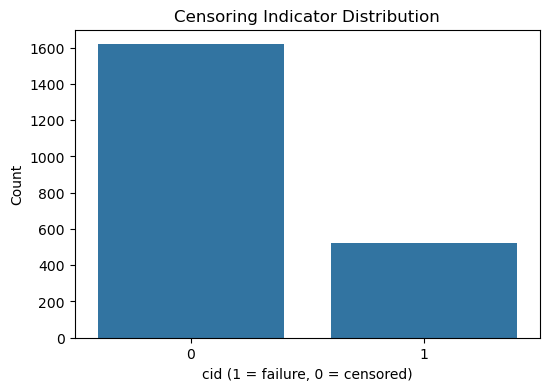

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='cid', data=df)
plt.title('Censoring Indicator Distribution')
plt.xlabel('cid (1 = failure, 0 = censored)')
plt.ylabel('Count')
plt.show()

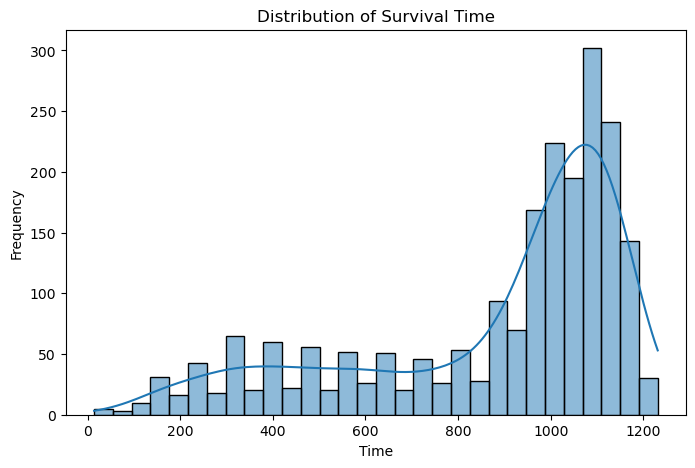

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['time'], bins=30, kde=True)
plt.title('Distribution of Survival Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

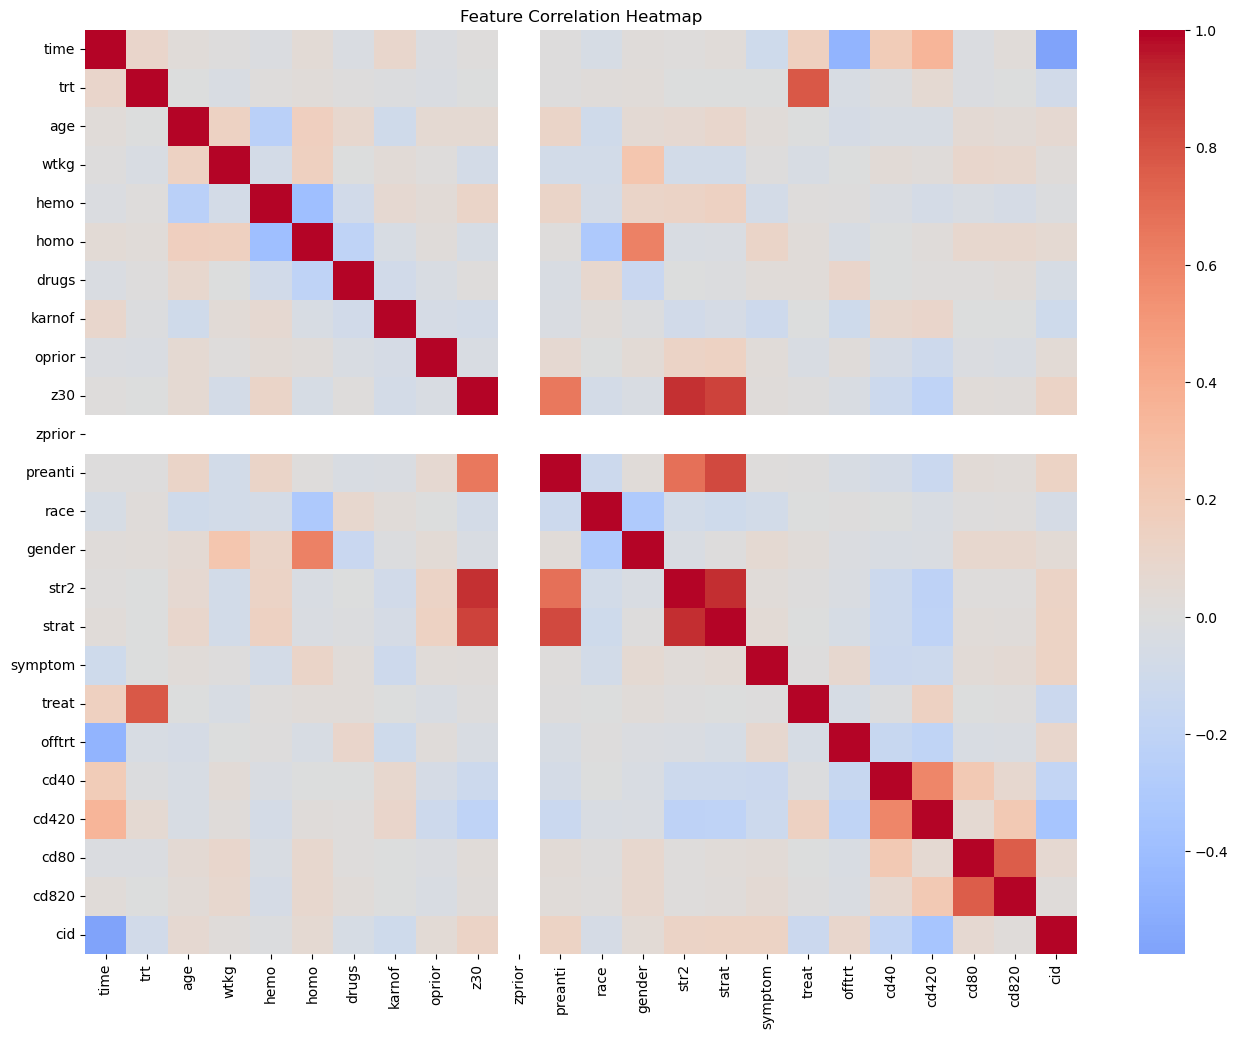

In [46]:
plt.figure(figsize=(16,12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

## Data Preprocessing

In [47]:
# Survival time
survival_time = df['time']

# Event indicator
survival_event = df['cid']

#Use important features from Pre Results
selected_features = [
    'offtrt',
    'symptom',
    'z30',
    'drugs',
    'oprior',
    'trt',
    'cd40',
    'cd420',
]

X = df[selected_features]

In [48]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [49]:
X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X_imputed,
    survival_time,
    survival_event,
    test_size=0.2,
    random_state=42,
    stratify=survival_event
)

## Model Training

### Cox Proportional Hazards

In [50]:
# Combine features with survival information
train_df = X_train.copy()
train_df['time'] = y_time_train.values
train_df['cid'] = y_event_train.values

# Test dataframe
test_df = X_test.copy()
test_df['time'] = y_time_test.values
test_df['cid'] = y_event_test.values


train_df_cox = train_df
test_df_cox = test_df

# Remove constant columns
constant_cols = [
    col for col in train_df_cox.columns
    if train_df_cox[col].nunique() <= 1
]

print('Constant columns:', constant_cols)

train_df_cox = train_df_cox.drop(columns=constant_cols)
test_df_cox = test_df_cox.drop(columns=constant_cols)

Constant columns: []


In [51]:
cox_model = CoxPHFitter(penalizer=0.1)

cox_model.fit(
    train_df_cox,
    duration_col='time',
    event_col='cid'
)

cox_risk = cox_model.predict_partial_hazard(
    test_df_cox.drop(columns=['time', 'cid'])
)

cox_cindex = concordance_index(
    y_time_test,
    -cox_risk,
    y_event_test
)

print(f"Cox PH Concordance Index: {cox_cindex:.4f}")

# Print summary
cox_model.print_summary()

Cox PH Concordance Index: 0.7611


<lifelines.CoxPHFitter: fitted with 1711 total observations, 1294 right-censored observations>
             duration col = 'time'
                event col = 'cid'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1711
number of events observed = 417
   partial log-likelihood = -2882.48
         time fit was run = 2026-06-03 12:30:49 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
offtrt     0.41      1.51      0.09            0.24            0.58                1.28                1.79
symptom    0.27      1.31      0.10            0.07            0.47                1.08                1.60
z30        0.16      1.17      0.09           -0.01            0.33                0.99                1.39
drugs     -0.23      0.80      0.13           -0.49            0.03                0.61                1.03
oprior    -0.12      0.89      0.25           -0.62            0.38                0.54                1.46
trt       -0.11      0.90      0.04           -0.18           -0.04                0.84                0.97
cd40      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cd420     -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

           cmp to      z      p  -log2(p)
covariate                                
offtrt       0.00   4.78 <0.005     19.13
symptom      0.00   2.70   0.01      7.16
z30          0.00   1.86   0.06      3.98
drugs        0.00  -1.71   0.09      3.52
oprior       0.00  -0.48   0.63      0.66
trt          0.00  -2.93 <0.005      8.20
cd40         0.00  -1.62   0.11      3.25
cd420        0.00 -10.84 <0.005     88.59
---
Concordance = 0.75
Partial AIC = 5780.97
log-likelihood ratio test = 240.68 on 8 df
-log2(p) of ll-ratio test = 155.43

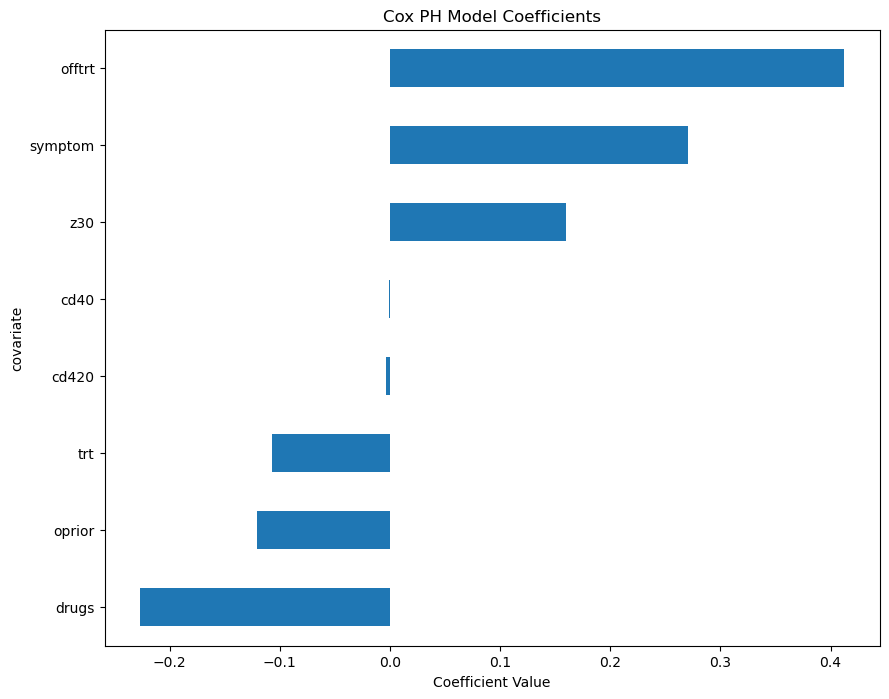

In [52]:
cox_summary = cox_model.summary

plt.figure(figsize=(10,8))
cox_summary['coef'].sort_values().plot(kind='barh')
plt.title('Cox PH Model Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

In [53]:
cox_model.check_assumptions(
    train_df_cox,
    p_value_threshold=0.05
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1711 total observations, 1294 right-censored observations>
         test_name = proportional_hazard_test

---
              test_statistic      p  -log2(p)
cd40    km              0.88   0.35      1.52
        rank            0.90   0.34      1.55
cd420   km             16.70 <0.005     14.48
        rank           16.99 <0.005     14.70
drugs   km              0.26   0.61      0.71
        rank            0.26   0.61      0.71
offtrt  km              6.41   0.01      6.46
        rank            6.58   0.01      6.60
oprior  km              1.30   0.25      1.97
        rank            1.41   0.23      2.09
symptom km              0.33   0.57      0.82
        rank            0.35   0.55      0.85
trt     km              0.92   0.34      1.56
        rank            0.88   0.35      1.52
z30     km              0.15   0.70      0.51
        rank            0.11   0.73      0.44



1. Variable 'offtrt' failed the non-proportional test: p-value is 0.0103.

   Advice: with so few unique values (only 2), you can include `strata=['offtrt', ...]` in the call
in `.fit`. See documentation in link [E] below.

2. Variable 'cd420' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'cd420' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'cd420' using pd.cut, and then specify it in `strata=['cd420',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedo

[]

In [54]:
# Partial hazard prediction
cox_risk_scores = cox_model.predict_partial_hazard(X_test)

# Concordance index
cox_cindex = concordance_index(
    y_time_test,
    -cox_risk_scores,
    y_event_test
)

print(f'Cox PH Concordance Index: {cox_cindex:.4f}')

Cox PH Concordance Index: 0.7611


In [55]:
hazard_ratios = pd.DataFrame({
    'Feature': cox_model.params_.index,
    'Coefficient': cox_model.params_.values,
    'Hazard Ratio': np.exp(cox_model.params_.values),
    'p-value': cox_model.summary['p'].values
})

hazard_ratios = hazard_ratios.sort_values(
    by='Hazard Ratio',
    ascending=False
)

print(hazard_ratios)

   Feature  Coefficient  Hazard Ratio       p-value
0   offtrt     0.412422      1.510472  1.749030e-06
1  symptom     0.270957      1.311219  6.990104e-03
2      z30     0.159638      1.173086  6.338669e-02
6     cd40    -0.000655      0.999346  1.050201e-01
7    cd420    -0.003892      0.996116  2.147752e-27
5      trt    -0.107224      0.898325  3.402968e-03
4   oprior    -0.121086      0.885958  6.342160e-01
3    drugs    -0.227195      0.796765  8.694909e-02


In [56]:
for _, row in hazard_ratios.iterrows():
    feature = row['Feature']
    hr = row['Hazard Ratio']

    if hr > 1:
        print(f'{feature}: increases patient risk (HR={hr:.3f})')
    elif hr < 1:
        print(f'{feature}: decreases patient risk (HR={hr:.3f})')
    else:
        print(f'{feature}: neutral effect')

offtrt: increases patient risk (HR=1.510)
symptom: increases patient risk (HR=1.311)
z30: increases patient risk (HR=1.173)
cd40: decreases patient risk (HR=0.999)
cd420: decreases patient risk (HR=0.996)
trt: decreases patient risk (HR=0.898)
oprior: decreases patient risk (HR=0.886)
drugs: decreases patient risk (HR=0.797)


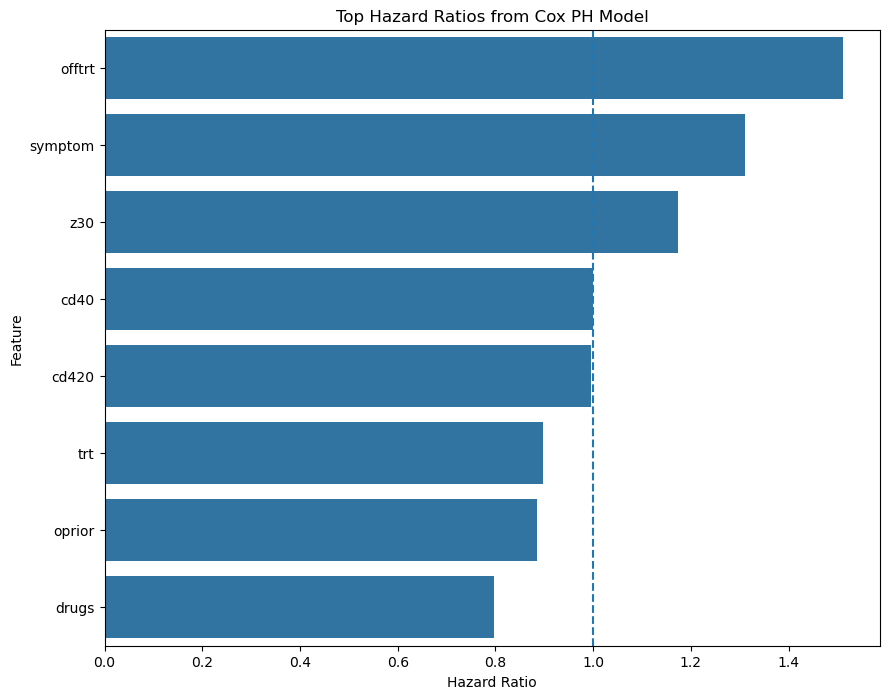

In [57]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=hazard_ratios.head(15),
    x='Hazard Ratio',
    y='Feature'
)

plt.axvline(1, linestyle='--')
plt.title('Top Hazard Ratios from Cox PH Model')
plt.show()

In [58]:
cox_risk_scores = cox_model.predict_partial_hazard(
    test_df_cox.drop(columns=['time', 'cid'])
)

risk_results = pd.DataFrame({
    'Patient_Index': range(len(cox_risk_scores)),
    'Risk_Score': cox_risk_scores.values.flatten(),
    'Observed_Time': y_time_test.values,
    'Event': y_event_test.values
})

print(risk_results.head())

   Patient_Index  Risk_Score  Observed_Time  Event
0              0    2.544626           1111      0
1              1    0.894233            812      0
2              2    2.671203            307      0
3              3    0.961122            980      0
4              4    1.209551           1049      0


In [59]:
median_risk = risk_results['Risk_Score'].median()

risk_results['Risk_Group'] = np.where(
    risk_results['Risk_Score'] >= median_risk,
    'High Risk',
    'Low Risk'
)

print(risk_results.head())

   Patient_Index  Risk_Score  Observed_Time  Event Risk_Group
0              0    2.544626           1111      0  High Risk
1              1    0.894233            812      0   Low Risk
2              2    2.671203            307      0  High Risk
3              3    0.961122            980      0   Low Risk
4              4    1.209551           1049      0  High Risk


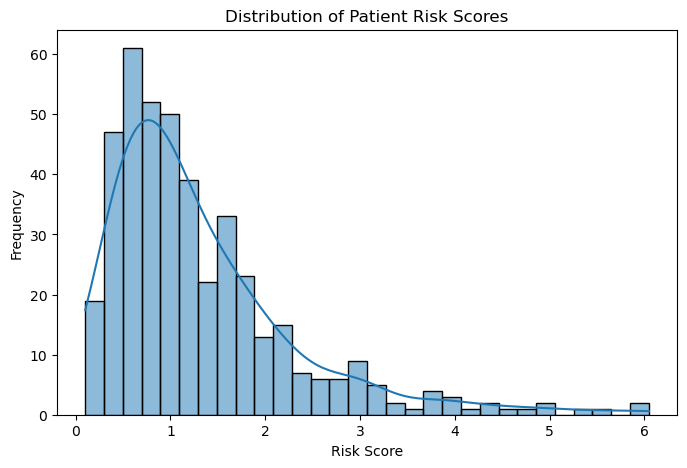

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(
    risk_results['Risk_Score'],
    bins=30,
    kde=True
)

plt.title('Distribution of Patient Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.show()

### Random Survival Forest

In [61]:
# Convert target into structured format required by scikit-survival

y_train_structured = Surv.from_arrays(
    event=y_event_train.astype(bool),
    time=y_time_train
)

y_test_structured = Surv.from_arrays(
    event=y_event_test.astype(bool),
    time=y_time_test
)

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
rsf_model = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rsf_model.fit(X_train_scaled, y_train_structured)

,n_estimators,200
,max_depth,None
,min_samples_split,10
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [64]:
rsf_risk_scores = rsf_model.predict(X_test_scaled)

In [65]:
rsf_cindex = concordance_index_censored(
    y_event_test.astype(bool),
    y_time_test,
    rsf_risk_scores
)[0]

print(f'Random Survival Forest Concordance Index: {rsf_cindex:.4f}')

Random Survival Forest Concordance Index: 0.7656


In [66]:
result = permutation_importance(
    rsf_model,
    X_test_scaled,
    y_test_structured,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
7    cd420    0.128869
0   offtrt    0.024576
5      trt    0.021587
6     cd40    0.010704
2      z30    0.006536
1  symptom    0.002356
4   oprior    0.000928
3    drugs    0.000631


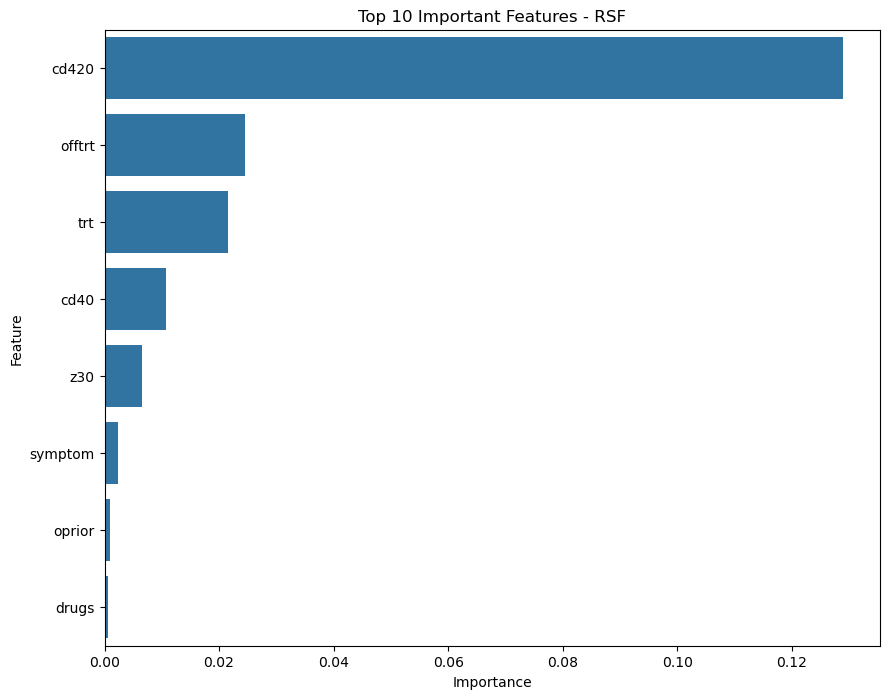

In [67]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features - RSF')
plt.show()

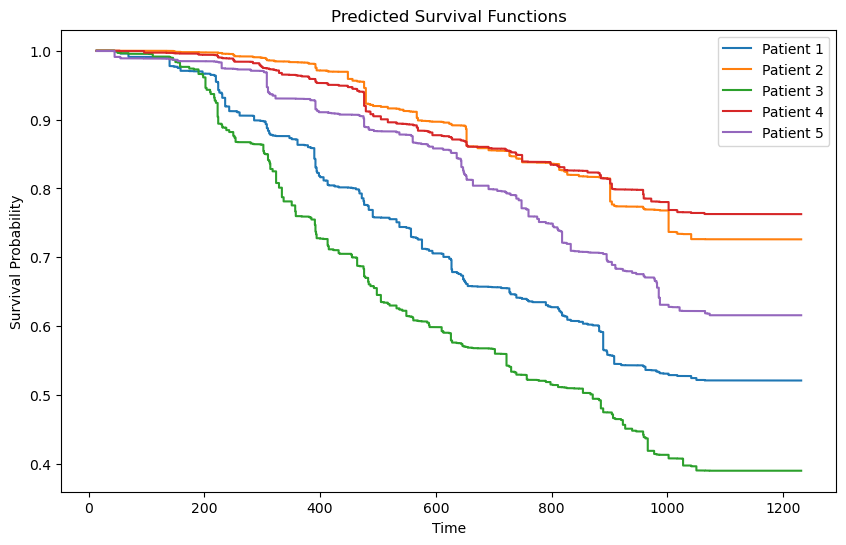

In [68]:
surv_functions = rsf_model.predict_survival_function(X_test_scaled[:5])

plt.figure(figsize=(10,6))

for i, surv_func in enumerate(surv_functions):
    plt.step(
        surv_func.x,
        surv_func.y,
        where='post',
        label=f'Patient {i+1}'
    )

plt.title('Predicted Survival Functions')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

## Model Comparison

In [69]:
comparison_df = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Random Survival Forest'],
    'Concordance Index': [cox_cindex, rsf_cindex]
})

print(comparison_df)

                      Model  Concordance Index
0  Cox Proportional Hazards           0.761102
1    Random Survival Forest           0.765598


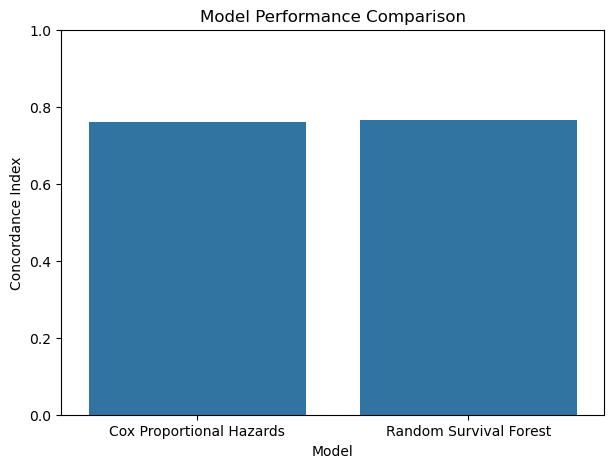

In [70]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Concordance Index'
)

plt.ylim(0, 1)
plt.title('Model Performance Comparison')
plt.show()

In [71]:
surv_functions = rsf_model.predict_survival_function(
    X_test_scaled[:5]
)

In [72]:
predicted_survival_times = []

for i, fn in enumerate(surv_functions):

    survival_probs = fn.y
    times = fn.x
    try:
        median_survival_time = times[
            np.where(survival_probs <= 0.5)[0][0]
        ]
    except:
        median_survival_time = np.max(times)

    predicted_survival_times.append(median_survival_time)

    print(
        f'Patient {i+1} predicted median survival time: '
        f'{median_survival_time:.2f}'
    )

Patient 1 predicted median survival time: 1231.00
Patient 2 predicted median survival time: 1231.00
Patient 3 predicted median survival time: 871.00
Patient 4 predicted median survival time: 1231.00
Patient 5 predicted median survival time: 1231.00


In [73]:
survival_prediction_df = pd.DataFrame({
    'Patient': [f'Patient {i+1}' for i in range(len(predicted_survival_times))],
    'Predicted_Median_Survival_Time': predicted_survival_times
})

print(survival_prediction_df)

     Patient  Predicted_Median_Survival_Time
0  Patient 1                          1231.0
1  Patient 2                          1231.0
2  Patient 3                           871.0
3  Patient 4                          1231.0
4  Patient 5                          1231.0


## Model Evaluation

In [74]:
evaluation = pd.DataFrame({
    'Model': ['Cox PH', 'Random Survival Forest'],
    'C-Index': [cox_cindex, rsf_cindex]
})

print(evaluation)

                    Model   C-Index
0                  Cox PH  0.761102
1  Random Survival Forest  0.765598


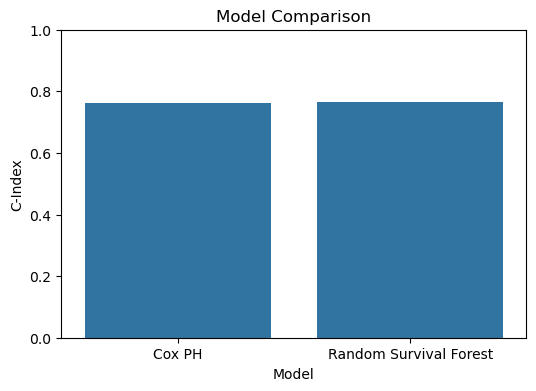

In [75]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=evaluation,
    x='Model',
    y='C-Index'
)

plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()

In [76]:
import joblib

joblib.dump(rsf_model, "rsf_model.pkl")
joblib.dump(cox_model, "cox_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully")

Model saved successfully
